In [ ]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

In [ ]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b master https://github.com/oreilly-japan/deep-learning-from-scratch-2.git
#%cd deep-learning-from-scratch-2
#sys.path.append('.')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from dataset import ptb
from common.time_layers import *
from common.optimizer import SGD

# 第５章 リカレントニューラルネットワーク (RNN)

## 5.1 確率と言語モデル
RNN を詳しく学ぶ前に、前章までの `word2vec` を「確率」の視点で捉え直し、言語を確率として扱う「言語モデル」について理解を深める。  

### 5.1.1 word2vec を確率の視点から考える
`word2vec` の CBOW モデルは、コンテキスト (周囲の単語) からターゲット (中央の単語) を推測する。  
コーパスを $w_1, w_2, \dots, w_T$ という単語の列としたとき、$t$ 番目の単語 $w_t$ をターゲット、$w_{t-1}$ と $w_{t+1}$ をコンテキストとする確率は、事後確率を用いて以下のように書ける。  

$$P(w_t | w_{t-1}, w_{t+1})$$

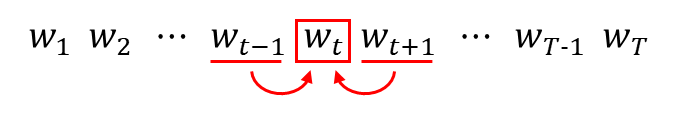

### 5.1.2 言語モデル
言語モデル (Language Model) は、単語の並びに対して確率を与える。  
単語の並び $w_1, \dots, w_m$ が出現する同時確率 $P(w_1, \dots, w_m)$ は、乗法定理を用いて以下のように事後確率の総乗で表せる。  

$$P(w_1, \dots, w_m) = \prod_{t=1}^{m} P(w_t | w_1, \dots, w_{t-1})$$

この事後確率は、「対象の単語より左側にあるすべての単語」をコンテキスト (条件) としている。  

### 5.1.3 CBOW モデルを言語モデルに？
CBOW モデルを無理やり言語モデル (条件付き言語モデル) に適用しようとすると、コンテキストのサイズを限定することになる。  

$$P(w_t | w_{1}, \dots, w_{t-1}) \approx P(w_t | w_{t-2}, w_{t-1})$$


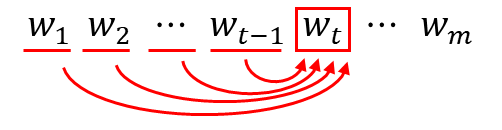

しかし、これには以下の問題がある。  

1. コンテキストサイズが固定：  
    そのサイズより左側にある情報を無視してしまう。  

2. 単語の並びが無視される：  
    CBOW の中間層は単語ベクトルの「和」であるため、順序の情報が失われる (Bag-of-Words)。  

⇒ これを解決するのが、本章のメインテーマである RNN  

#### 言語モデルの基礎：条件付き確率の計算
言語モデルの直感を掴むために、非常にシンプルな「カウントベースの言語モデル」を作成し、特定の文脈の後にどの単語が来やすいかを計算する。  

In [ ]:
def simple_language_model_stats(text):
    text = text.lower().replace('.', ' .')
    words = text.split(' ')

    # 2 つの単語の並び (Bigram) をカウント
    bigrams = [(words[i], words[i+1]) for i in range(len(words)-1)]
    bigram_counts = Counter(bigrams)
    word_counts = Counter(words)

    return bigram_counts, word_counts

def get_next_word_prob(query_word, bigram_counts, word_counts):
    print(f"--- '{query_word}' の次に来る単語の確率 ---")

    # query_word から始まる Bigram を抽出
    relevant_bigrams = {k: v for k, v in bigram_counts.items() if k[0] == query_word}

    if not relevant_bigrams:
        print("データが見つかりません。")
        return

    for (w1, w2), count in relevant_bigrams.items():
        # 条件付き確率 P(w2|w1) = Count(w1, w2) / Count(w1)
        prob = count / word_counts[w1]
        print(f" P({w2} | {w1}) = {prob:.4f}")

In [ ]:
# 実験用のテキスト
text = "You say goodbye and I say hello."
bigram_counts, word_counts = simple_language_model_stats(text)

get_next_word_prob("you", bigram_counts, word_counts)
get_next_word_prob("say", bigram_counts, word_counts)

#### 5.1 節のまとめ
* 言語モデルの目標は、ある単語までの流れ $w_1, \dots, w_{t-1}$ を受けて、次の単語 $w_t$ が出現する確率を求めること。  

* 従来のモデル (CBOW など) は、過去の長い情報を記憶し続けたり、単語の順序を考慮したりするのが不得意。  

* RNN はこれらの問題を解決し、任意の長さのコンテキストを考慮できるメカニズムを持っている。  

## 5.2 RNN とは
RNN (Recurrent Neural Network) は、その名の通り「循環する」構造を持つニューラルネットワークである。これにより、過去の情報を記憶しながら、時系列データを処理することが可能になる。  

### 5.2.1 循環するニューラルネットワーク
RNN の特徴は、レイヤがループする経路を持っていることです。  

#### RNN レイヤの基本構造 (ループ形式)
データが循環する様子を視覚化する。  

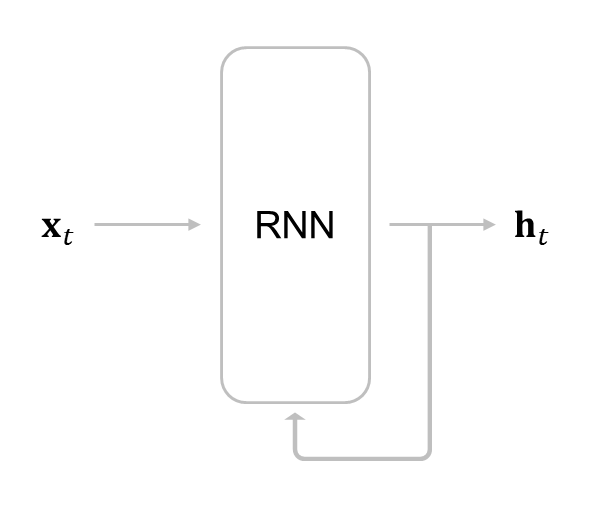

実際の計算では、出力された $h_t$ のコピーが次時刻の入力として自分自身に戻る。  

### 5.2.2 ループの展開
RNN のループ構造を展開すると、複数の RNN レイヤが横に並んだ、馴染みのあるフィードフォワード型のネットワークとして解釈できる。ただし、これらすべてのレイヤは「重みを共有する同じレイヤ」である点に注意が必要。  

#### 時間方向に展開した RNN
時刻 $t-1, t, t+1$ の流れを表す。  

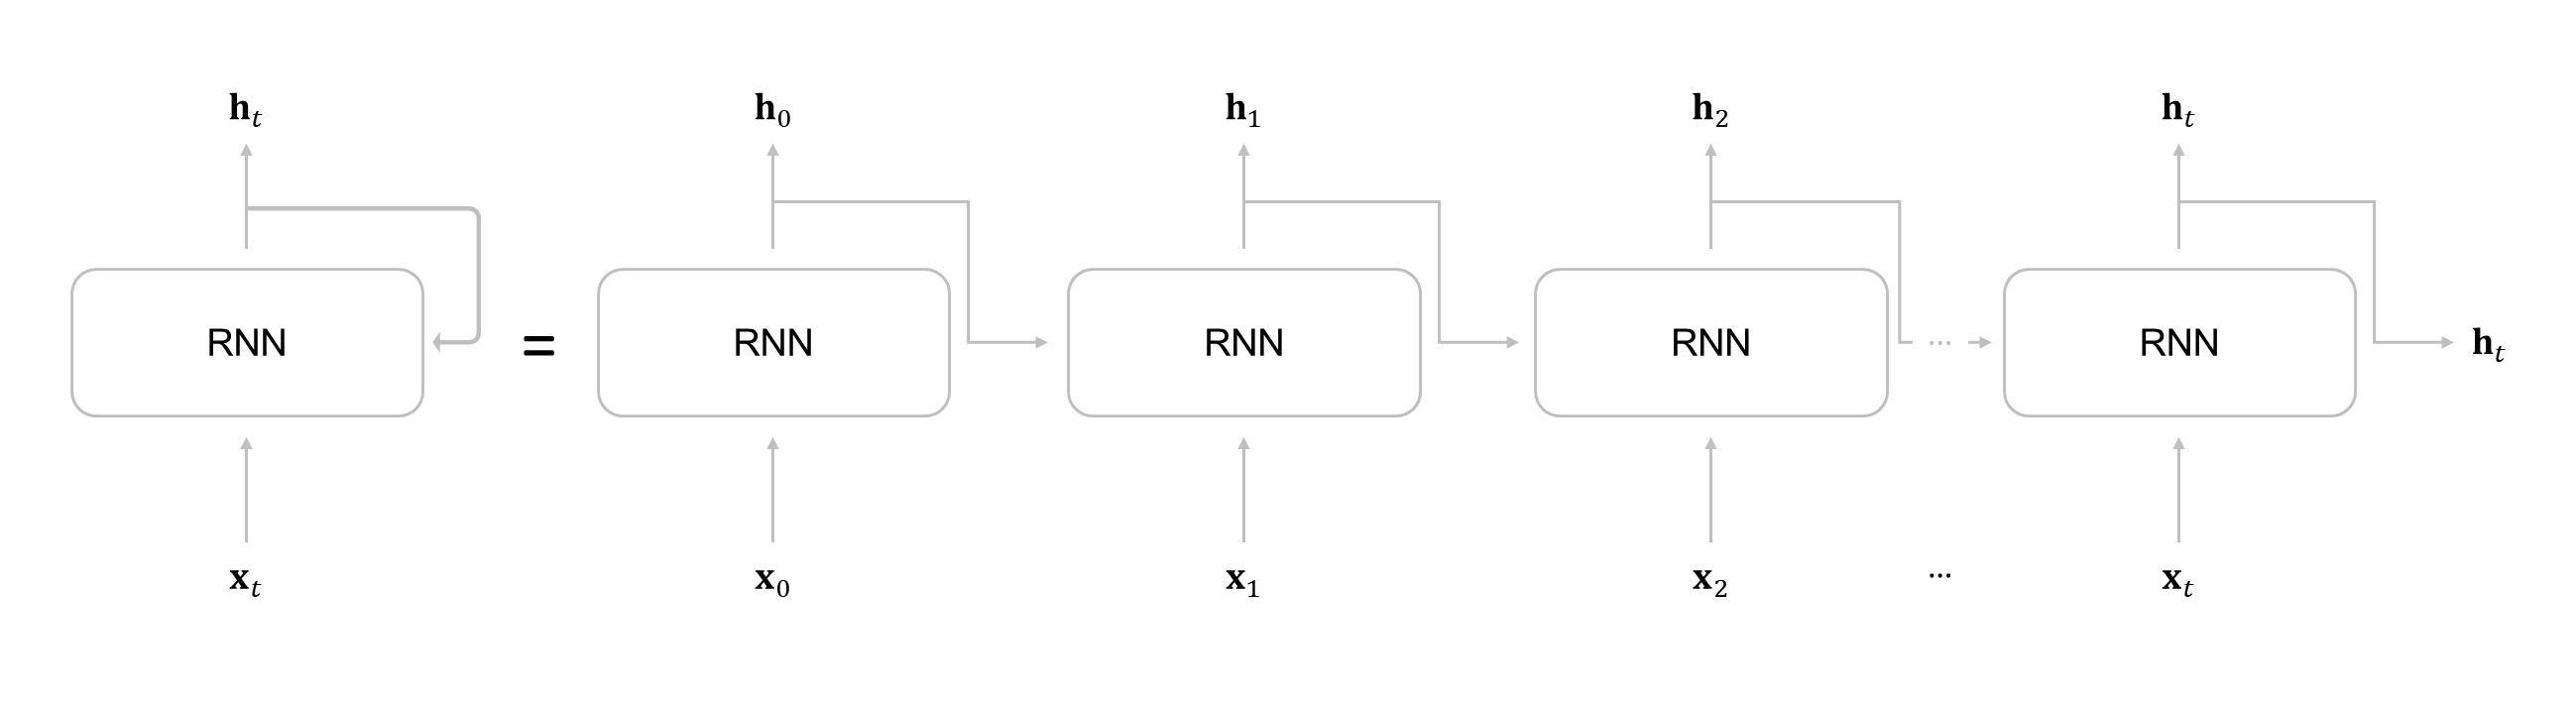

#### RNNの計算式
各時刻での出力 $h_t$ (隠れ状態) は以下の式で計算される。  

$$h_t = \tanh(h_{t-1}W_h + x_tW_x + b)$$

* $W_x$：入力 $x$ を出力 $h$ に変換するための重み。  

* $W_h$：次の時刻の出力に変換するための重み。  

* $h_t$：隠れ状態 (hidden state)、過去の情報を記憶したベクトル。  


### 5.2.3 Backpropagation Through Time (BPTT)
展開した RNN に対して通常の誤差逆伝播法を適用することを BPTT と呼ぶ。しかし、長い時系列データをそのまま扱うと、計算リソースの増大や勾配消失・爆発の問題が発生する。  

### 5.2.4 Truncated BPTT
長い時系列データを学習する際は、ネットワークのつながりを適当な長さで「断ち切る」手法を取る。これを Truncated BPTT と呼ぶ。  

* 逆伝播のつながりのみ断ち切る。  

* 順伝播のつながりは維持するため、データは「シーケンシャル (順番通り)」に与える必要がある。  


#### Truncated BPTT によるブロック学習

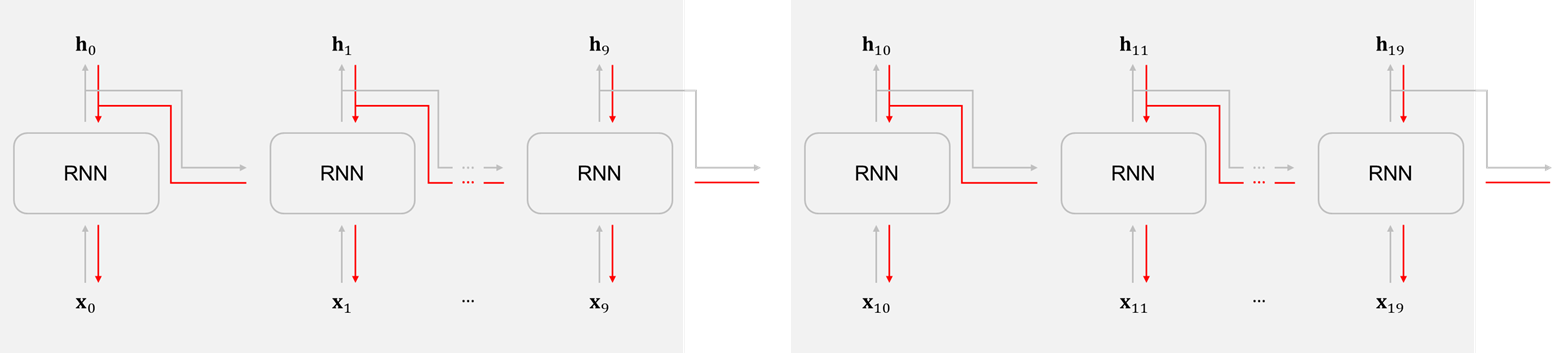

#### tanh 関数の性質の可視化
RNN の活性化関数として使われる `tanh` 関数が、逆伝播時にどのように勾配を減衰させるかを確認する実験を追加する。  

In [ ]:
def tanh(x):
    return np.tanh(x)

def tanh_grad(x):
    return 1 - np.tanh(x)**2

In [ ]:
x = np.arange(-5.0, 5.0, 0.1)
y = tanh(x)
dy = tanh_grad(x)

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='tanh(x)')
plt.plot(x, dy, label="tanh'(x) (gradient)", linestyle='--')
plt.title("tanh function and its gradient")
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid()
plt.show()

print("勾配の最大値:", np.max(dy))

グラフからわかる通り、`tanh` の勾配 (点線) は最大でも 1.0 であり、0 から遠ざかるほど急激に小さくなる。これが RNN で勾配消失が起きやすい理由の一つである。  

#### 5.2 節のまとめ
* RNN はループする経路によって状態 (隠れ状態 $h$) を内部に記憶する。  

* 長い時系列では、逆伝播をブロックごとに切り取る Truncated BPTT を使う。  

* Truncated BPTT では、データの順序を守って (シーケンシャルに) 隠れ状態を引き継ぐことが不可欠である。  

## 5.3 RNN の実装
ここでは、これまでに学んだ RNN の構造を実際に Python で実装する。実装のモジュール性を高めるため、以下の 2 つのクラスに分けて作成する。  

1. RNN クラス：時系列の「1 ステップ」の処理を行うレイヤ。  

2. TimeRNN クラス：$T$ ステップ分の処理をまとめて行うレイヤ。  

### 5.3.1 RNN レイヤの実装
まずは 1 ステップの順伝播 (Forward) と逆伝播 (Backward) を実装する。RNN の計算式を再掲する。  

$$h_t = \tanh(h_{t-1}W_h + x_tW_x + b)$$

#### 行列の形状チェック
実装時には、行列のサイズ (形状) が一致しているかを確認することが非常に重要である。  
* $x_t$: $(N, D)$  
    $N$：バッチサイズ、$D$：入力次元

* $h_{t-1}$: $(N, H)$  
    $H$：隠れ状態の次元

* $W_x$: $(D, H)$  

* $W_h$: $(H, H)$  

* $b$: $(H,)$  

In [ ]:
class RNN:
    def __init__(self, Wx, Wh, b):
        """
        初期化
        """
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev):
        """
        順伝播
        """
        Wx, Wh, b = self.params
        t = np.dot(h_prev, Wh) + np.dot(x, Wx) + b
        h_next = np.tanh(t)

        self.cache = (x, h_prev, h_next)
        return h_next

    def backward(self, dh_next):
        """
        逆伝播
        """
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache

        # tanh の微分
        dt = dh_next * (1 - h_next ** 2)

        # 各パラメータの勾配
        db = np.sum(dt, axis=0)
        dWh = np.dot(h_prev.T, dt)
        dh_prev = np.dot(dt, Wh.T)
        dWx = np.dot(x.T, dt)
        dx = np.dot(dt, Wx.T)

        # 勾配を保存、... は全ての要素を更新することを意味
        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

        return dx, dh_prev

### 5.3.2 Time RNN レイヤの実装
`TimeRNN` レイヤは、$T$ 個の `RNN` レイヤを連結したネットワークである。このクラスは、ブロック間での隠れ状態 $h$ の引き継ぎを管理する役割も担う。  

* `stateful`：  
    隠れ状態を維持するかどうかのフラグである。  
    `True` の場合、どんなに長い時系列でも順伝播を断ち切らずに伝播させる。  

In [ ]:
class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.dh = None, None
        self.stateful = stateful

    def set_state(self, h):
        self.h = h

    def reset_state(self):
        self.h = None

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        D, H = Wx.shape

        self.layers = []
        hs = np.empty((N, T, H), dtype='f')

        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype='f')

        for t in range(T):
            layer = RNN(*self.params)
            self.h = layer.forward(xs[:, t, :], self.h)
            hs[:, t, :] = self.h
            self.layers.append(layer)

        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D, H = Wx.shape

        dxs = np.empty((N, T, D), dtype='f')
        dh = 0
        grads = [0, 0, 0]
        # 時系列を逆向きにループ
        for t in reversed(range(T)):
            layer = self.layers[t]
            # 上流からの勾配 dhs と、未来の時刻からの勾配 dh を合算して入力
            dx, dh = layer.backward(dhs[:, t, :] + dh)
            dxs[:, t, :] = dx

            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        # まとめた勾配をインスタンス変数に設定
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dh

        return dxs

#### 5.3 節のまとめ
* RNN クラスは 1 ステップの「計算グラフ」を忠実に実装する。  

* TimeRNN クラスはこれらを複数束ね、$T$ ステップの行列演算として扱えるようにする。  

* stateful 管理により、Truncated BPTT に必要な「隠れ状態の引き継ぎ」が自動化される。  

* 逆伝播では、上流からの勾配と「未来の時刻から戻ってきた勾配」を合算して一つ前の時刻へ渡す。  


## 5.4 時系列データを扱うレイヤの実装
本節の目標は、RNN を用いて「言語モデル (RNNLM: RNN Language Model)」を構築することである。これまでに実装した `TimeRNN` に加え、他のレイヤ (Embedding, Affine, Softmax) も時系列データをまとめて処理できるように拡張する。  

### 5.4.1 RNNLM の全体図
RNNLM は、主に 4 つの層 (レイヤ) が重なった構成をとる。  

1. Embedding レイヤ：  
    単語 ID を単語の分散表現 (ベクトル) へ変換する。  

2. RNN レイヤ：  
    前の時刻の情報を引き継ぎながら、現在の入力を処理する。  

3. Affine レイヤ：  
    RNN の出力を、語彙数と同じサイズのスコアへ変換する。  

4. Softmax レイヤ：  
    スコアを確率分布へ変換し、次にくる単語を予測する。  

RNN レイヤが過去の情報を隠れ状態として「記憶」し、それを次時刻へ伝達することで、「you say」という文脈の後に「goodbye」や「hello」が来る確率を高く見積もることができるようになります。  

### 5.4.2 Time レイヤの実装
時系列データを $T$ ステップ分まとめて処理するレイヤを、本書では「Timeレイヤ」と呼ぶ (例：`TimeAffine`、`TimeEmbedding`)。これにより、時系列ネットワークをレゴブロックのように簡単に組み合わせることが可能になる。  

#### Time レイヤの考え方
各時刻のデータを個別に処理するレイヤを $T$ 個並べるイメージですが、実装上は「行列計算」としてまとめて処理することで効率化を図る。  

* Time Affine レイヤ：  
    $T$ 個の `Affine` レイヤを束ねたもの。  

* Time Softmax with Loss レイヤ：  
    $T$ 個の損失を合算し、その平均を最終的な損失 $L$ とする。  

$$L = \frac{1}{T} \sum_{t=0}^{T-1} L_t$$

#### Time レイヤの概念 (簡易版)
ここでは、スコアの時系列データ `xs` と教師ラベルの時系列データ `ts` を受け取り、平均損失を計算する `TimeSoftmaxWithLoss` の骨組みを確認する。  

In [ ]:
# 共通レイヤを管理する common/layers.py から SoftmaxWithLoss をインポートする想定
# ここでは動作確認のためダミーの関数を定義
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        x = np.exp(x)
        x /= x.sum(axis=1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)
        exp_x = np.exp(x)
        x = exp_x / np.sum(exp_x)
    return x

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 教師データが one-hot-vector の場合、正解ラベルのインデックスに変換
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

class TimeSoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
        self.ignore_label = -1

    def forward(self, xs, ts):
        """
        xs: スコアの時系列データ (N, T, V)
        ts: 教師ラベルの時系列データ (N, T)
        """
        N, T, V = xs.shape

        if ts.ndim == 3:  # 教師ラベルがone-hotベクトルの場合
            ts = ts.argmax(axis=2)

        mask = (ts != self.ignore_label)

        # バッチ分と時系列分をまとめる（reshape）
        # (N, T, V) -> (N*T, V) に整形して通常の Softmax を一括適用
        xs = xs.reshape(N * T, V)
        ts = ts.reshape(N * T)
        mask = mask.reshape(N * T)

        ys = softmax(xs)
        ls = np.log(ys[np.arange(N * T), ts])
        ls *= mask  # ignore_labelに該当するデータは損失を0にする
        loss = -np.sum(ls)
        loss /= mask.sum()

        self.cache = (ts, ys, mask, (N, T, V))
        return loss

    def backward(self, dout=1):
        ts, ys, mask, (N, T, V) = self.cache

        dx = ys
        dx[np.arange(N * T), ts] -= 1
        dx *= dout
        dx /= mask.sum()
        dx *= mask[:, np.newaxis]  # ignore_labelに該当するデータは勾配を0にする

        dx = dx.reshape((N, T, V))

        return dx

#### 5.4 節のまとめ
* RNNLM は、Embedding、RNN、Affine、Softmax を積み重ねたネットワークである。  

* Time レイヤは、時系列データを「一括して」処理するための工夫であり、内部では行列の形状を一時的に変えることで効率的に計算している。  

* 全体の損失は、各時刻の損失の平均として算出される。  

## 5.5 RNNLM の学習と評価

これまでに実装した各 Time レイヤ (Embedding, RNN, Affine, Softmax with Loss) を組み合わせ、一つの「言語モデル」として統合する。これを RNNLM (RNN Language Model) と呼ぶ。  

### 5.5.1 RNNLM の実装
ここでは、4 つの Time レイヤを重ねた `SimpleRnnlm` クラスを実装する。  

#### SimpleRnnlm の構造

```mermaid
graph TD
    XS((入力: xs)) --> Embed[Time Embedding]
    Embed --> RNN[Time RNN]
    RNN --> Affine[Time Affine]
    Affine --> Softmax[Time Softmax with Loss]
    TS((教師: ts)) --> Softmax
    Softmax --> Loss((損失: Loss))

    style RNN fill:#f9f,stroke:#333
    style Softmax fill:#c8e6c9,stroke:#2e7d32
```

#### SimpleRnnlm クラス
このクラスは、Truncated BPTT による学習を想定し、RNN の隠れ状態を保持する `stateful=True` の設定で初期化する。  

In [ ]:
class TimeEmbedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.layers = None
        self.W = W

    def forward(self, xs):
        N, T = xs.shape
        V, D = self.W.shape

        out = np.empty((N, T, D), dtype='f')
        self.layers = []

        for t in range(T):
            layer = Embedding(self.W)
            out[:, t, :] = layer.forward(xs[:, t])
            self.layers.append(layer)

        return out

    def backward(self, dout):
        N, T, D = dout.shape

        grad = 0
        for t in range(T):
            layer = self.layers[t]
            layer.backward(dout[:, t, :])
            grad += layer.grads[0]

        self.grads[0][...] = grad
        return None

In [ ]:
# common/time_layers.py などから各レイヤをインポートする想定
# ここではこれまでの節で定義したクラスを使用します

class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 重みの初期化 (Xavier の初期値を利用)
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # レイヤの生成
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # すべての重みと勾配をリストにまとめる
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer.forward(xs, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()

### 5.5.2 言語モデルの評価：パープレキシティ (Perplexity)
言語モデルの予測性能を評価する指標として、パープレキシティ (perplexity) がよく用いられます。

* 直感的な意味：  
    「確率の逆数」であり、次にくる単語の **「平均分岐数（候補数）」** と解釈できる。  

* 値の見方：  
    小さければ小さいほど良いモデルです。例えば Perplexity = 1.25 なら候補を約1個に絞れており、5.0 ならまだ5個の候補で迷っている状態を指します。  

* 計算式：  
    交差エントロピー誤差を $L$ としたとき、$e^L$ で求められます。  

#### 損失と Perplexity の関係の可視化
損失 (Cross Entropy Loss) が減少するにつれて、Perplexity (分岐数) がどのように絞られていくかをシミュレーションする。  

In [ ]:
losses = np.linspace(0, 5, 100)
perplexities = np.exp(losses)

plt.figure(figsize=(8, 5))
plt.plot(losses, perplexities, color='darkorange', linewidth=2)
plt.xlabel("Loss (Cross Entropy)")
plt.ylabel("Perplexity (Branching Factor)")
plt.title("Relationship between Loss and Perplexity")
plt.grid(True, linestyle='--')
plt.axvline(1.0, color='red', linestyle=':', label='Loss=1.0 (PPL ≈ 2.72)')
plt.legend()
plt.show()

### 5.5.3 RNNLM の学習
RNNLM の学習では、Truncated BPTT を正しく機能させるために、データを「シーケンシャル (順番通り)」かつ「開始位置をズラして (オフセット)」与える必要がある。  

#### 学習用メインループ
PTB データセットの先頭 1,000 単語を用いて学習を行う。  

In [ ]:
# ※ 実行には dataset/ptb.py と、前述の Time 系レイヤの定義が必要
# ハイパーパラメータの設定
batch_size = 10
wordvec_size = 100
hidden_size = 100
time_size = 5  # Truncated BPTT の展開サイズ
lr = 0.1
max_epoch = 100

# データの読み込み (PTB の一部を使用)
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]  # 入力データ
ts = corpus[1:]  # 教師データ (入力の 1 つ先)
data_size = len(xs)
print(f"コーパスサイズ: {data_size}, 語彙数: {vocab_size}")

# 学習時に使用する変数
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []

# モデルの生成
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)

# ミニバッチの開始位置の計算 (offsets)
jump = (corpus_size - 1) // batch_size
offsets = [i * jump for i in range(batch_size)]

# 学習のループ
for epoch in range(max_epoch):
    # max_iters 分だけミニバッチを取得して学習
    for iter in range(max_iters):
        # ミニバッチの取得
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')

        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]
            time_idx += 1

        # 勾配を求め、パラメータを更新
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1

    # エポックごとにパープレキシティの評価
    ppl = np.exp(total_loss / loss_count)
    print(f'| epoch {epoch+1} | perplexity {ppl:.2f}')
    ppl_list.append(float(ppl))
    total_loss, loss_count = 0, 0

### 5.5.4 RNNLM の Trainer クラス
実際の開発では、上記のような複雑なループを手書きする代わりに、本書が提供する `RnnlmTrainer` クラスを利用することで、データのシーケンシャルな供給や勾配クリッピングなどを自動化できる。  

#### 5.5 節のまとめ
* SimpleRnnlm は複数の Time レイヤを積み重ねただけのシンプルな構成。  

* Perplexity は「次にくる単語を何個まで絞り込めているか」を表す平均分岐数である。  

* データの与え方が非常に重要であり、Truncated BPTT を有効にするために各ミニバッチの開始地点をズラしてシーケンシャルに読み込む。  

## 5.6 まとめ

本章では、時系列データを扱うためのリカレントニューラルネットワーク (RNN) について、その基本原理から実装、そして評価方法までを詳しく学習した。  

## 本章の振り返り
本章で学んだ重要なポイントは以下の通りである。  

- 循環する構造：RNN はループする経路を持つことで、過去の情報を「隠れ状態」として内部に記憶し、次時刻へと引き継ぐことができる。  

- BPTT と Truncated BPTT：RNN の学習には、時間方向に展開して誤差逆伝播を行う BPTT を用いる。長い時系列データに対しては、逆伝播のつながりだけを適当な長さで切り取る Truncated BPTT が有効である。  

- データの与え方：Truncated BPTT を正しく機能させるには、データを「シーケンシャル (順番通り)」に与え、かつ各ミニバッチの開始位置をズラして読み込む必要がある。  

- 言語モデル (RNNLM)：RNN を用いて、これまでの単語の流れを「記憶」し、次にくる単語を予測する言語モデルを構築した。  

- 評価指標：言語モデルの予測性能は、次にくる単語の候補を平均して何個に絞れているかを表すパープレキシティ (Perplexity) で評価する。  

## 次章の内容：シンプルな RNN の限界と「ゲート」の必要性

本章で完成させた「シンプルな RNN」には、実は実用上の大きな弱点がある。それは、「長期の依存関係」を学習するのが非常に苦手であるという点。  

### シンプルな RNN が抱える問題
* 勾配消失：遠く離れた過去の情報が、現在に届くまでに勾配が極端に小さくなり、学習に反映されなくなる。  

* 勾配爆発：逆に、勾配が指数的に大きくなり、ネットワークが不安定（NaN など）になる。  

「Tom がテレビを見ていた……（中略）……Mary は [?] に挨拶した」という問題で、正解の「Tom」を思い出すには、今の RNN のままでは力不足。  

### 解決の鍵は「ゲート」
次章では、この問題を根本から解決するために考案された「ゲート付き RNN」の世界に入門する。  

* LSTM (Long Short-Term Memory)：「忘れる」「覚える」「出力する」をコントロールする 3 つのゲートを持つ、現代の標準的な RNN である。  

* GRU (Gated Recurrent Unit)：LSTM をよりシンプルにしたバリエーションである。  